## 1. Setup e Extração

In [1]:
# Bibliotecas padrão do Python
import os
import unicodedata
import numpy as np

# Bibliotecas de terceiros (Manipulação e Visualização)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Sklearn (Machine Learning - Processamento e Modelagem)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# Carga dos dados
df = pd.read_excel('base_customer.xlsx')

## 2. Limpeza Inicial e Padronização

### Seleção de Variáveis

Dentre as 27 colunas disponíveis, foram selecionadas apenas as variáveis com valor analítico para segmentação comportamental e financeira.
A tabela abaixo documenta a decisão para cada coluna:

| COLUNA | TIPO | DESCRIÇÃO | AÇÃO |
|---|---|---|---|
| CLIENTE | Texto | Identificador nominal sem valor analítico para agrupamento | `Remover` |
| TRANSACAO | Texto | Identificador único, não contribui para padrões de comportamento | `Remover` |
| DATA ORDEM | Data/Hora | Irrelevante para análise de engajamento | `Remover` |
| DATA APROVACAO | Data | Valores quase iguais a data_ordem, vai gerar ruído no cluster | `Remover` |
| STATUS | Texto | Coluna sem variação relevante para segmentação | `Remover` |
| PAGAMENTO | Texto | Alta cardinalidade e redundante com outras variáveis | `Remover` |
| PAGAMENTO TRATADO | Texto | Informação redundante e pouco discriminativa para clusters | `Remover` |
| TIPO PAGAMENTO | Numérico | Variável categórica codificada, ruim para K-Means sem semântica ordinal | `Remover` |
| **TOTAL PARCELAS** | **Numérico** | **Indica comprometimento financeiro** | **Manter** |
| **RECORRENTE** | **Numérico** | **Diferencia modelo de pagamento (assinatura vs avulso)** | **Manter** |
| ULTIMO ACESSO | Data/Hora | Representação já capturada numericamente em DIAS SEM ACESSAR | `Remover` |
| **ATIVO** | **Texto** | **Indica status atual do cliente na plataforma** | **Manter** |
| **NUM ACESSOS** | **Numérico** | **Mede intensidade de uso — proxy de valor percebido** | **Manter** |
| RECORRENCIA | Numérico | Informação redundante com a coluna n_acessos | `Remover` |
| **DIAS SEM ACESSAR** | **Numérico** | **Forte indicador de risco de churn** | **Manter** |
| ID ALUNO | Numérico | Identificador técnico sem relevância analítica | `Remover` |
| CRIADO NA WATI | Texto | Informação de origem pouco relevante para segmentação comportamental | `Remover` |
| DATA BOAS VINDAS | Data/Hora | Coluna com múltiplos significados — violação de normalização | `Remover` |
| ATUAL % DE CONCLUSÃO | Numérico | Todos os valores estão zerados na base atual | `Remover` |
| ACOMP. MENSAL | Data | Alta quantidade de nulos e baixa padronização | `Remover` |
| NPS | Data | Dados incompletos e não consistentes para clustering | `Remover` |
| FINALIZOU CURSO? | Texto | Variável muito esparsa e com baixa completude | `Remover` |
| EPOCA NPS | Texto | Variável operacional sem impacto direto no comportamento | `Remover` |
| EPOCA FUP | Texto | Variável de processo interno, não comportamental | `Remover` |
| 1 ANO APOS DATA COMPRA | Data | Irrelevante para a análise de segmentação | `Remover` |
| **RENOVACAO** | **Numérico** | **Indicador direto de retenção e fidelização, relevante para unir a base clusterizada** | **Manter** |
| TEM COMUNIDADE? | Texto | Coluna sem definição clara e com muitos nulos | `Remover` |

In [2]:
def normalize_columns(col):
    col = col.strip().lower().replace(' ', '_')
    col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
    return col

df.columns = [normalize_columns(col) for col in df.columns]

# Remoção das colunas irrelevantes identificadas na tabela de variáveis
cols_to_drop = [
    'cliente', 'transacao', 'aluno_id', 'criado_na_wati', 
    'acomp._mensal', 'nps', 'finalizou_curso?', 'epoca_nps', 
    'epoca_fup', 'tem_comunidade?', 'pagamento', 'pagamento_tratado',
    '1_ano_apos_data_compra', 'data_aprovacao', 'atual_%_de_conclusao',
    'tipo_pagamento', 'recorrencia','status'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

df.columns.tolist()

['data_ordem',
 'total_parcelas',
 'recorrente',
 'ultimo_acesso',
 'ativo',
 'n_acessos',
 'dias_sem_acessar',
 'boas_vindas',
 'renovacao']

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45815 entries, 0 to 45814
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data_ordem        45815 non-null  datetime64[us]
 1   total_parcelas    45815 non-null  int64         
 2   recorrente        45815 non-null  int64         
 3   ultimo_acesso     37854 non-null  datetime64[us]
 4   ativo             45815 non-null  str           
 5   n_acessos         45815 non-null  int64         
 6   dias_sem_acessar  45815 non-null  int64         
 7   boas_vindas       45569 non-null  object        
 8   renovacao         45815 non-null  int64         
dtypes: datetime64[us](2), int64(5), object(1), str(1)
memory usage: 3.1+ MB


## 3. Análise Exploratória e Validação

In [4]:
# Check de Nulos
df.isnull().sum()

data_ordem             0
total_parcelas         0
recorrente             0
ultimo_acesso       7961
ativo                  0
n_acessos              0
dias_sem_acessar       0
boas_vindas          246
renovacao              0
dtype: int64

In [5]:
# Validação de Acessos
df[df['ultimo_acesso'].isna()]['n_acessos'].value_counts()

n_acessos
0    7961
Name: count, dtype: int64

In [6]:
df[df['ultimo_acesso'].isna()]['dias_sem_acessar'].value_counts()

dias_sem_acessar
0    7961
Name: count, dtype: int64

In [7]:
# Validação coluna boas_vindas
# Apenas ~1% está nulo ou seja, ~99% dos clientes que nunca acessaram RECEBERAM boas-vindas,
# indicando que não é um problema de onboarding ausente — é problema de onboarding ineficaz.
df[df['ultimo_acesso'].isna()][['boas_vindas']].isna().mean()

boas_vindas    0.010175
dtype: float64

## 4. Carga e Verificação Final

In [8]:
# Tratar coluna 'ativo'
df['ativo'] = df['ativo'].replace('não identificado', 'não')
df['ativo'] = df['ativo'].map({'não': 0, 'sim': 1}).fillna(0).astype(int)


# Imputar 'dias_sem_acessar' para quem nunca acessou

DATA_REF = pd.Timestamp('2026-02-20')  # data de extração da base

mask_nunca = (df['n_acessos'] == 0) & (df['dias_sem_acessar'] == 0)

df.loc[mask_nunca, 'dias_sem_acessar'] = (
    DATA_REF - df.loc[mask_nunca, 'data_ordem']
).dt.days

# Remover colunas que não serão mais utilizadas
df = df.drop(columns=[
    'boas_vindas',
    'data_ordem',
    'ultimo_acesso',
], errors='ignore')

# Visualização final
df.columns.tolist()

['total_parcelas',
 'recorrente',
 'ativo',
 'n_acessos',
 'dias_sem_acessar',
 'renovacao']

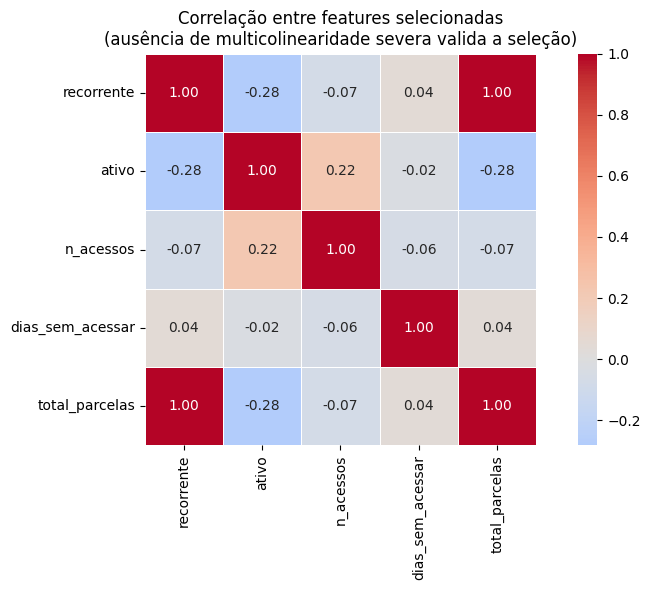

In [9]:
# Selecionando as colunas numéricas
features = ['recorrente','ativo','n_acessos','dias_sem_acessar','total_parcelas']

#  Matriz de correlação entre as  features finais
corr = df[features].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 10}
)
plt.title('Correlação entre features selecionadas\n(ausência de multicolinearidade severa valida a seleção)', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Padronização (Scaling)

In [10]:
# Configuração do Scaler para retornar Pandas DataFrame
scaler = StandardScaler().set_output(transform="pandas")

# Ajuste e transformação direta
df_scaled = scaler.fit_transform(df[features])

## 6. Cálculo da Inércia

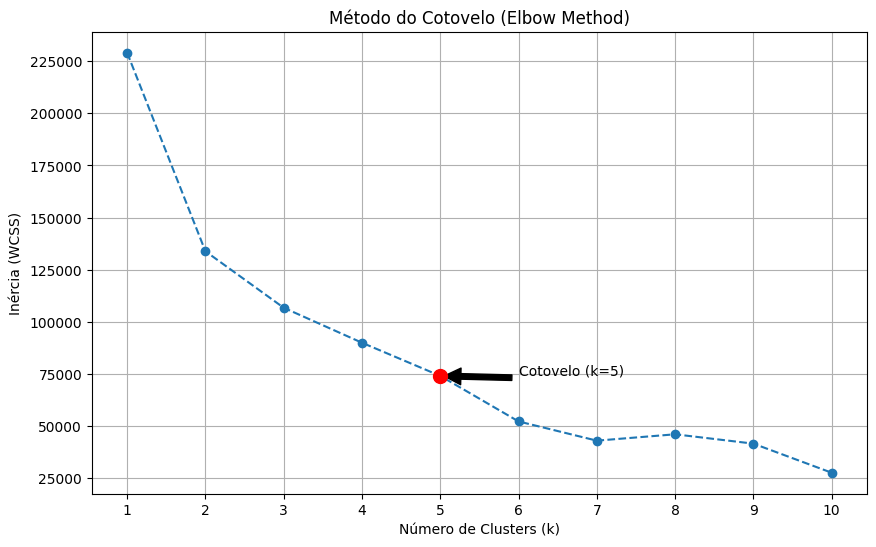

In [11]:
# Testando de 1 a 10 clusters
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotagem do Gráfico
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)


# Destacando o ponto k=5
k_alvo = 5
plt.scatter(k_alvo, wcss[k_alvo-1], color='red', s=100, zorder=5)
plt.annotate('Cotovelo (k=5)', 
             xy=(k_alvo, wcss[k_alvo-1]), 
             xytext=(k_alvo+1, wcss[k_alvo-1]+500), # Ajuste o +500 conforme sua escala
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()


## 7. Treinar ou carregar modelo

In [12]:
MODEL_PATH = 'cluster_model.pkl'

if os.path.exists(MODEL_PATH):
    print("Carregando modelo existente...")
    model = joblib.load(MODEL_PATH)
else:
    model = KMeans(n_clusters=5, random_state=42, n_init='auto')
    model.fit(df_scaled)
    joblib.dump(model, MODEL_PATH)
    print("Modelo treinado e salvo.")

Modelo treinado e salvo.


## 8. Aplicação final

In [13]:
df['cluster'] = model.predict(df_scaled)

## 9. Análise dos clusters

In [14]:
# Tamanho de cada cluster
df['cluster'].value_counts()

cluster
3    19078
1    12393
2     7968
0     3334
4     3042
Name: count, dtype: int64

In [15]:
# Score com K=5
score = silhouette_score(df_scaled, df['cluster'], sample_size=5000, random_state=42)
print(f'Silhouette Score K=5: {score:.3f}')

# Comparação entre diferentes valores de K
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels, sample_size=5000, random_state=42)
    print(f'K={k}: {score:.3f}')

Silhouette Score K=5: 0.547
K=2: 0.483
K=3: 0.502
K=4: 0.480
K=5: 0.547
K=6: 0.583
K=7: 0.595
K=8: 0.490
K=9: 0.494
K=10: 0.591


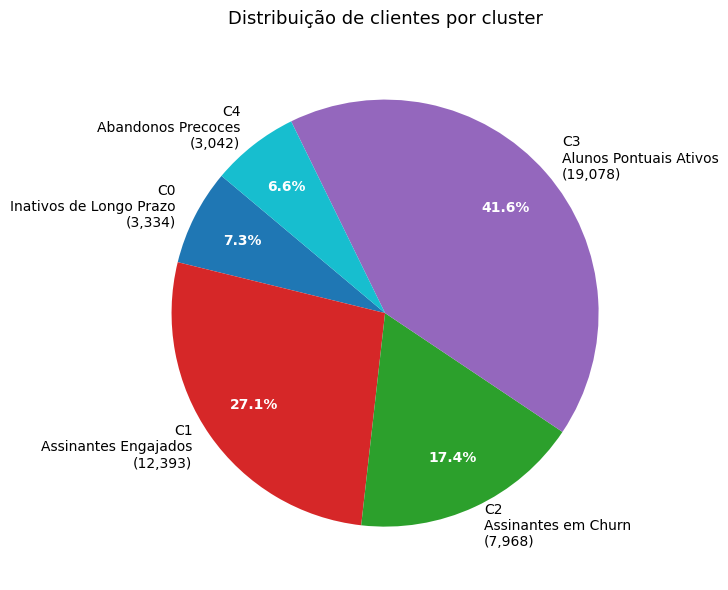

In [16]:
# Distribuição de clientes por cluster
nomes_clusters = {
    0: 'Inativos de Longo Prazo',
    1: 'Assinantes Engajados',
    2: 'Assinantes em Churn',
    3: 'Alunos Pontuais Ativos',
    4: 'Abandonos Precoces'
}

cores_clusters = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#17becf']

sizes = df['cluster'].value_counts().sort_index()
labels_pizza = [f"C{i}\n{nomes_clusters[i]}\n({v:,})" for i, v in sizes.items()]

plt.figure(figsize=(9, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels_pizza,
    autopct='%1.1f%%',
    startangle=140,
    colors=cores_clusters,
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('white')
    at.set_fontweight('bold')

plt.title('Distribuição de clientes por cluster', fontsize=13, pad=16)
plt.tight_layout()
plt.show()

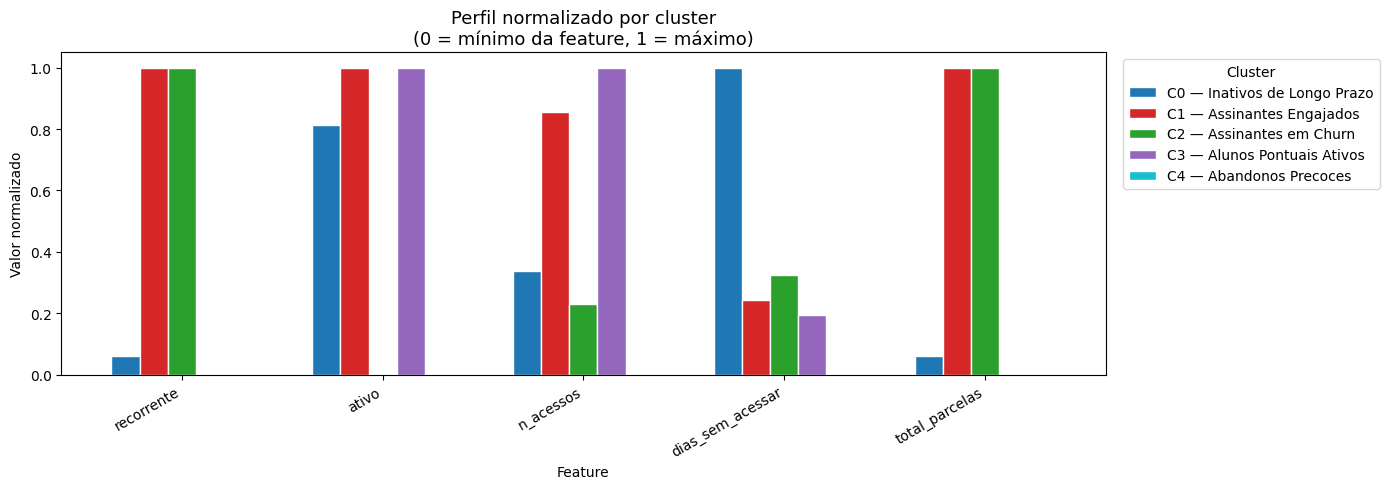

In [17]:
# Médias por cluster
cluster_means = df.groupby('cluster')[features].mean()

# Normalização min-max para comparação visual entre features de escalas diferentes
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

ax = cluster_means_norm.T.plot(
    kind='bar',
    figsize=(14, 5),
    color=cores_clusters,
    edgecolor='white',
    width=0.7
)
plt.title('Perfil normalizado por cluster\n(0 = mínimo da feature, 1 = máximo)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Valor normalizado')
plt.xticks(rotation=30, ha='right')
plt.legend(
    title='Cluster',
    labels=[f'C{i} — {nomes_clusters[i]}' for i in range(5)],
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

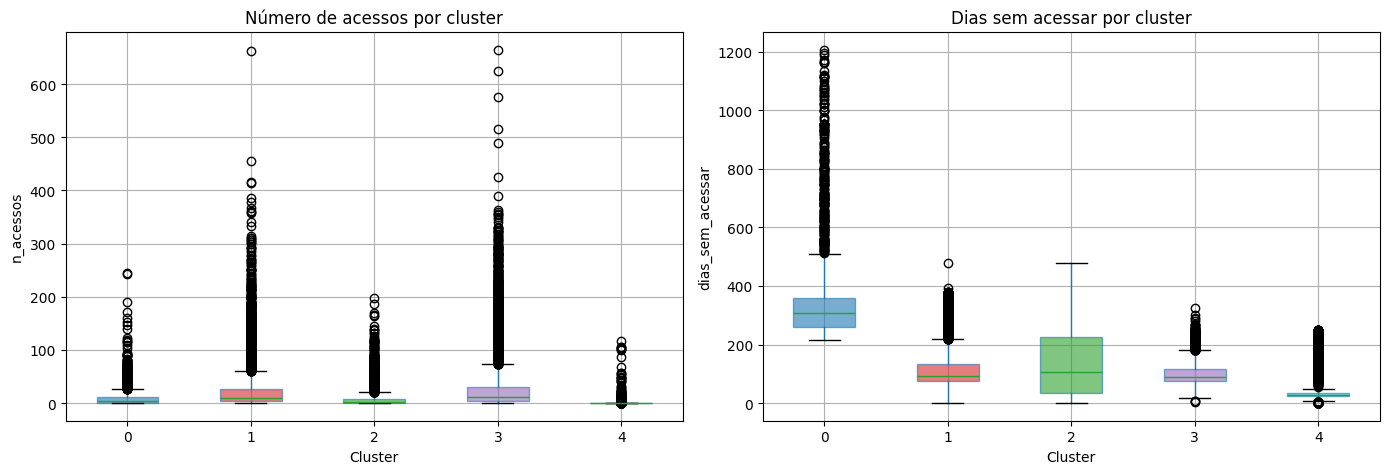

In [18]:
# Boxplot - analisando a dispersão interna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp1 = df.boxplot(column='n_acessos', by='cluster', ax=axes[0],
                 patch_artist=True, return_type='both')
for patch, color in zip(bp1['n_acessos'][1]['boxes'], cores_clusters):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('Número de acessos por cluster', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('n_acessos')

bp2 = df.boxplot(column='dias_sem_acessar', by='cluster', ax=axes[1],
                 patch_artist=True, return_type='both')
for patch, color in zip(bp2['dias_sem_acessar'][1]['boxes'], cores_clusters):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Dias sem acessar por cluster', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('dias_sem_acessar')

plt.suptitle('')
plt.tight_layout()
plt.show()

# A presença de outliers nos boxplots reflete a heterogeneidade natural do comportamento de usuários em plataformas digitais
# Optei por não removê-los pois representam comportamentos legítimos — sua exclusão eliminaria clientes reais e distorceria a segmentação

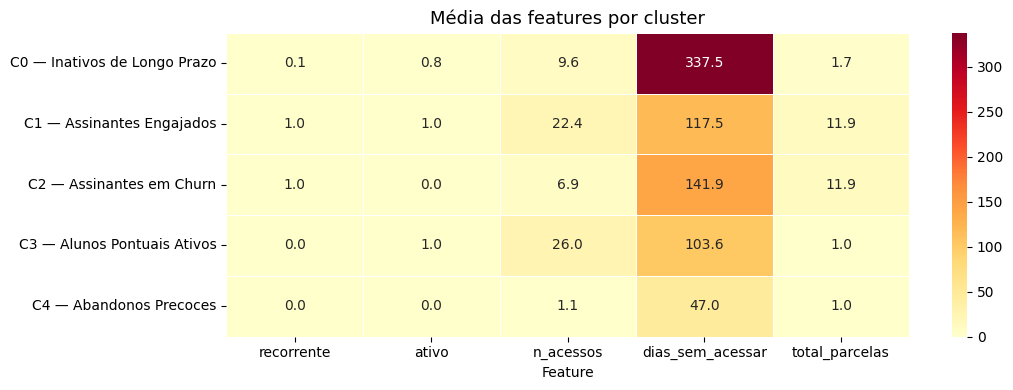

In [19]:
# Heatmap com nomes dos clusters nos eixos
plt.figure(figsize=(11, 4))
sns.heatmap(
    cluster_means,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    yticklabels=[f'C{i} — {nomes_clusters[i]}' for i in cluster_means.index]
)
plt.title('Média das features por cluster', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [20]:
# Tabela síntese com nome, tamanho e médias de cada cluster
perfil_final = cluster_means.copy().round(2)
perfil_final.insert(0, 'nome', [nomes_clusters[i] for i in perfil_final.index])
perfil_final.insert(1, 'n_clientes', df['cluster'].value_counts().sort_index().values)
perfil_final.insert(2, 'pct_base', (perfil_final['n_clientes'] / len(df) * 100).round(1).astype(str) + '%')
perfil_final.index = [f'C{i}' for i in perfil_final.index]

display(perfil_final)

,nome,n_clientes,pct_base,recorrente,ativo,n_acessos,dias_sem_acessar,total_parcelas
C0,Inativos de Longo Prazo,3334,7.3%,0.06,0.81,9.57,337.52,1.66
C1,Assinantes Engajados,12393,27.1%,1.00,1.00,22.36,117.48,11.93
C2,Assinantes em Churn,7968,17.4%,1.00,0.00,6.85,141.88,11.93
C3,Alunos Pontuais Ativos,19078,41.6%,0.00,1.00,25.96,103.57,1.00
C4,Abandonos Precoces,3042,6.6%,0.00,0.00,1.14,47.04,1.00


In [21]:
df.to_excel('base_cluster.xlsx', index=False)

## 10. Predict para classificar novos clientes

In [22]:
NEW_BASE_PATH = 'new_base_customer.xlsx'

if os.path.exists(NEW_BASE_PATH):
    print("Clusterizando nova base de clientes")

    pipeline = joblib.load('cluster_model.pkl')
    df_new = pd.read_excel('new_base_customer.xlsx')
    df_new.columns = [normalize_columns(col) for col in df_new.columns]

    df_new['ativo'] = df_new['ativo'].replace('não identificado', 'não')
    df_new['ativo'] = df_new['ativo'].map({'não': 0, 'sim': 1}).fillna(0).astype(int)

    # Imputar 'dias_sem_acessar' para quem nunca acessou

    DATA_REF = pd.Timestamp('2026-02-20')  # data de extração da base

    new_mask_nunca = (df_new['n_acessos'] == 0) & (df_new['dias_sem_acessar'] == 0)

    df_new.loc[new_mask_nunca, 'dias_sem_acessar'] = (
    DATA_REF - df_new.loc[new_mask_nunca, 'data_ordem']
    ).dt.days


    new_base_features = ['recorrente','ativo','n_acessos','dias_sem_acessar','total_parcelas']
    
    X = df_new[new_base_features]
    df_new['cluster'] = pipeline.predict(X)
    df_new.to_excel('new_base_cluster.xlsx', index=False)

else:
    print("new_base_customer.xlsx não encontrado")

Clusterizando nova base de clientes


In [23]:
# Verificando os Clusters da nova base de clientes
print(df_new['cluster'].value_counts())

cluster
0    886
1    108
2      4
3      2
Name: count, dtype: int64


In [24]:
# Tabela síntese com nome, tamanho e médias de cada cluster
cluster_means = df_new.groupby('cluster')[new_base_features].mean()

new_perfil_final = cluster_means.copy().round(2)
new_perfil_final.insert(0, 'nome', [nomes_clusters[i] for i in new_perfil_final.index])
new_perfil_final.insert(1, 'n_clientes', df_new['cluster'].value_counts().sort_index().values)
new_perfil_final.insert(2, 'pct_base', (new_perfil_final['n_clientes'] / len(df_new) * 100).round(1).astype(str) + '%')
new_perfil_final.index = [f'C{i}' for i in new_perfil_final.index]

display(new_perfil_final)

,nome,n_clientes,pct_base,recorrente,ativo,n_acessos,dias_sem_acessar,total_parcelas
C0,Inativos de Longo Prazo,886,88.6%,0.43,0.8,20.67,139.06,5.64
C1,Assinantes Engajados,108,10.8%,0.54,0.3,0.64,0.91,6.91
C2,Assinantes em Churn,4,0.4%,1.00,0.0,0.20,7.58,11.97
C3,Alunos Pontuais Ativos,2,0.2%,0.50,1.0,442.07,73.10,6.53


## 11. Análise dos Clusters — Respostas às Perguntas de Negócio

---
 
### 1. Quantos grupos distintos de clientes existem na base? Qual critério foi usado para essa escolha?
 
Foram identificados **5 grupos distintos de clientes** na base da Insight Academy.
 
A escolha de K=5 foi baseada em 2 critérios combinados:
 
- **Método do Cotovelo (Elbow):** ao testar valores de K entre 2 e 10, a curva de inércia (WCSS) apresentou reduções expressivas até K=5, com desaceleração clara a partir desse ponto. Apesar de K=6 também apresentar redução relevante, o ganho marginal não justificou a complexidade adicional de interpretação.
- **Silhouette Score:** confirmou K=5 como melhor equilíbrio entre coesão interna e separação entre clusters, com score de **0.547** — superior a K=3 (0.502) e K=4 (0.480), e muito proximo a K=6 (0.583) com menor complexidade.
---

### 2. Qual é o perfil de cada grupo?
 
| Cluster | Nome                      | Clientes | % Base | Parcelas (média) | % Recorrente | % Ativo | Acessos (média) | Dias Inativo (média) | % Renovação |
|---------|---------------------------|---------:|-------:|-----------------:|-------------:|---------:|-----------------:|---------------------:|------------:|
| 0       | C0 — Inativos de Longo Prazo| 3.334    | 7,3%   | 1,66             | 6,0%         | 81,0%    | 9,6              | 337,5                | 26,0%       |
| 1       | C1 — Assinantes ativos    | 12.393   | 27,1%  | 11,93            | 100,0%       | 100,0%   | 22,4             | 117,5                | 12,0%       |
| 2       | C2 — Assinantes em risco  | 7.968    | 17,4%  | 11,93            | 100,0%       | 0,0%     | 6,9              | 141,9                | 0,0%        |
| 3       | C3 — Avulsos engajados    | 19.078   | 41,6%  | 1                | 0,0%         | 100,0%   | 26,0             | 103,6                | 11,0%       |
| 4       | C4 — Dormentes recentes   | 3.042    | 6,6%   | 1                | 0,0%         | 0,0%     | 1,1              | 47,0                 | 0,0%        |
 
**Descrição qualitativa:**
 
- **C0 — Inativos de Longo Prazo:** Clientes muito antigos, quase sem acesso há ~338 dias. Poucos são recorrentes. Maioria pagou à vista. Alta taxa de renovação (26%) sugere que alguns mantêm contrato mesmo sem usar.

Risco: alto abandono silencioso

- **C1 — Assinantes ativos:** 100% recorrentes, 100% ativos. Média de 22 acessos, parcelamento em 12x. Bom engajamento, mas taxa de renovação baixa (12%) indica risco de churn após 1 ano.

Perfil: core valioso — manter e fidelizar

- **C2 — Assinantes em risco:** 100% recorrentes mas 0% ativos. Média de apenas 6,9 acessos, 142 dias sem entrar. Taxa de renovação zero. Estão pagando sem consumir — candidatos a churn imediato.

Risco crítico: pagam mas não usam

- **C3 — Avulsos engajados:** Maior cluster. Compram cursos avulsos (à vista, 1x), são ativos (100%) e têm a maior média de acessos (26). Inatividade recente de 104 dias. Grande potencial de conversão para assinatura.

Oportunidade: conversão para recorrência

- **C4 — Dormentes recentes:** Compraram avulso mas mal acessaram (média 1,1 acesso). Inativos há 47 dias — os mais recentes. 0% renovação. Provavelmente nunca iniciaram o curso. Janela de reativação ainda aberta.

Oportunidade: reativação urgente — ainda é cedo

---

### 3. Existe algum grupo que se destaca positivamente? E negativamente? Por quê?
 
**Destaque positivo — C3 (Avulsos engajados):**
É o maior cluster da base com 19.078 clientes (41,6%) e apresenta a maior média de acessos de todos os grupos (26 acessos), com 100% dos clientes ativos. O mais relevante é que esse engajamento é espontâneo: esses clientes compraram cursos avulsos à vista, sem qualquer vínculo de assinatura ou recorrência que os obrigue a acessar. Isso significa que o interesse é genuíno e o comportamento é orientado por motivação própria, não por contrato. São clientes que chegaram, pagaram e voltaram por conta própria. Esse perfil é o mais saudável da base e representa o maior potencial de conversão para planos recorrentes, já que a empresa não precisaria criar engajamento porque ele já existe.

**Destaque negativo — C2 (Assinantes em risco):**
É o cenário mais preocupante da base por uma razão objetiva: representa uma contradição financeira ativa. São 7.968 clientes (17,4%) que possuem plano de assinatura recorrente, ou seja, estão gerando receita mensal, mas têm 0% de clientes ativos na plataforma, média de apenas 6,9 acessos no histórico total e taxa de renovação absolutamente zero. Isso significa que a empresa está recebendo o pagamento mas não entregando valor percebido. Quando esses contratos vencerem, não haverá nenhuma razão para o cliente renovar, pois ele simplesmente não lembra que a plataforma existe. A empresa está em uma posição silenciosamente perigosa: a receita parece estável no curto prazo, mas o churn em massa está programado para acontecer no momento do vencimento. Além do risco financeiro, há um risco de reputação, pois clientes que pagaram e nunca foram ativados tendem a ter NPS muito negativo quando finalmente percebem que não usaram o serviço.

---

### 4. Existem clientes com plano recorrente que não acessam a plataforma? Qual o tamanho desse grupo?
 
Sim. O cluster **C2 (Assinantes em Risco)** concentra esse problema.
 
8.418 clientes (18,4% da base) com plano recorrente e 3 ou menos acessos — concentrados principalmente no C2.
 
---

### 5. Que ações de marketing, retenção ou vendas a empresa deveria adotar para cada grupo?
 
| Cluster | Segmento | Diagnóstico | Recomendações | Prioridade |
|---|---|---|---|---|
| C0 | **Inativos de Longo Prazo**<br>3.334 clientes (7,3%) | Clientes muito antigos (338 dias sem acesso). Baixo engajamento histórico. Maioria comprou avulso. Alguns mantêm contrato mesmo inativos. | • Campanha de reativação segmentada (e-mail + oferta exclusiva)<br>• Pesquisa de motivo de abandono (NPS de saída)<br>• Oferta de downgrade para plano básico<br>• Para recorrentes: contato proativo antes do vencimento | **4° - Média** |
| C1 | **Assinantes ativos**<br>12.393 clientes (27,1%) | Core da base. Recorrentes, ativos, 22 acessos em média. Parcelados em 12x. Risco de churn após término do contrato (renovação apenas 12%). | • Programa de fidelidade e certificados de conclusão<br>• Upsell: acesso a novos cursos premium<br>• Campanha de renovação 60 dias antes do vencimento<br>• Incentivar comunidade e mentoria para aumentar NPS | **3° - Alta** |
| C2 | **Assinantes em risco**<br>7.968 clientes (17,4%) | Pagam assinatura recorrente mas têm 0% ativos, quase sem acessos (6,9) e zero renovações. Risco crítico de churn com perda de receita recorrente. | • Onboarding de emergência: sequência de e-mails com trilha personalizada<br>• Ligação/chat do CS para entender barreira de uso<br>• Oferta de sessão de tutoria gratuita<br>• Gatilho automático: se 30 dias sem acesso → contato imediato<br>• Considerar campanha de winback antes do cancelamento | **1° - Crítica** |
| C3 | **Avulsos engajados**<br>19.078 clientes (41,6%) | Maior cluster. Compram à vista, são muito ativos (26 acessos), mas não são recorrentes. Alto potencial de conversão para assinatura. | • Campanha de conversão para plano de assinatura com desconto<br>• Mostrar valor incremental: acesso ilimitado a 40+ cursos<br>• Cross-sell: cursos complementares ao que já fez<br>• Gamificação: trilhas de aprendizado com progresso visível<br>• Oferta de trial de 30 dias no plano recorrente | **5° - Baixa** |
| C4 | **Dormentes recentes**<br>3.042 clientes (6,6%) | Compraram recentemente mas quase não acessaram (1,1 acesso). Inativos há só 47 dias. Janela de reativação ainda aberta — não iniciaram o conteúdo. | • Onboarding imediato: e-mail de boas-vindas com primeiros passos<br>• Checklist de início: "Sua primeira aula em 10 minutos"<br>• Reminder automatizado: 7, 14 e 30 dias sem acesso<br>• Suporte ativo do CS nas primeiras semanas<br>• Vídeo tutorial do produto na plataforma | **2° - Urgente** |

---

### 6. Se um novo cliente se cadastrar amanhã, como classificá-lo automaticamente em um dos grupos?
 
O modelo salvo em `cluster_model.pkl` contém um pipeline com o `StandardScaler` e o `KMeans` já integrados, permitindo classificar novos clientes automaticamente com `predict()`.

Para utilizá-lo, basta colocar na mesma pasta um arquivo com o nome `new_base_customer.xlsx` e rodar o código — ele aplica o modelo salvo e classifica os clientes automaticamente, sem necessidade de retreinar.
O processo aplica exatamente os mesmos tratamentos usados na base de treinamento antes de classificar: